In [69]:
osm_png_path = r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\osm_ref.png"
bplan_png_path = r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\output\bplan_clipped.png"
liegenschaft_png_path = r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\output\liegenschaftkataster.png"

In [ ]:
# SuperGlue mit lokalem Modul verwenden
import sys
import os
import cv2
import numpy as np
import torch

# Füge den PARENT-Pfad hinzu, damit Python das Paket erkennt
parent_path = r"c:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\SuperGlue_model"
sys.path.insert(0, parent_path)


from models.matching import Matching
from models.utils import frame2tensor

print(f"✅ Module erfolgreich geladen!")

# Konfiguration für SuperGlue
config = {
    'superpoint': {
        'nms_radius': 4,
        'keypoint_threshold': 0.005,  # Niedriger = mehr Keypoints
        'max_keypoints': 1024
    },
    'superglue': {
        'weights': 'outdoor',  # 'indoor' oder 'outdoor'
        'sinkhorn_iterations': 20,
        'match_threshold': 0.2,  # Höher = strengere Matches
    }
}

# Lade Bilder (in Graustufen für SuperPoint)
img1 = cv2.imread(liegenschaft_png_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(bplan_png_path, cv2.IMREAD_GRAYSCALE)

# Resize für bessere Performance (optional)
IMAGE_SIZE = 640
img1_resized = cv2.resize(img1, (IMAGE_SIZE, IMAGE_SIZE))
img2_resized = cv2.resize(img2, (IMAGE_SIZE, IMAGE_SIZE))

print(f"Bild 1: {img1_resized.shape}")
print(f"Bild 2: {img2_resized.shape}")

# Erstelle Matcher
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

matching = Matching(config).eval().to(device)

# Konvertiere zu Tensoren
inp1 = frame2tensor(img1_resized, device)
inp2 = frame2tensor(img2_resized, device)

# Führe Matching durch
with torch.no_grad():
    pred = matching({'image0': inp1, 'image1': inp2})

# Extrahiere Keypoints und Matches
kpts0 = pred['keypoints0'][0].cpu().numpy()
kpts1 = pred['keypoints1'][0].cpu().numpy()
matches = pred['matches0'][0].cpu().numpy()
confidence = pred['matching_scores0'][0].cpu().numpy()

# Filtere valid matches (matches >= 0)
valid = matches > -1
mkpts0 = kpts0[valid]
mkpts1 = kpts1[matches[valid]]
match_confidence = confidence[valid]

# gib mir eine variable wo ich die maximale anzahl der matches einstellen kann
MAX_MATCHES = 100  


if len(mkpts0) > MAX_MATCHES:
    # Ssortiere nach confidence und nimm die besten
    best_indices = np.argsort(match_confidence)[::-1][:MAX_MATCHES]
    mkpts0 = mkpts0[best_indices]
    mkpts1 = mkpts1[best_indices]
    match_confidence = match_confidence[best_indices]
    print(f"⚠️  Matches limitiert auf TOP {MAX_MATCHES} (von {len(kpts0[valid])} gefunden)")

print(f"\n✅ SuperGlue Ergebnisse:")
print(f"   Keypoints Bild 1: {len(kpts0)}")
print(f"   Keypoints Bild 2: {len(kpts1)}")
print(f"   Verwendete Matches: {len(mkpts0)}")
print(f"   Confidence range: [{match_confidence.min():.3f}, {match_confidence.max():.3f}]")

✅ Module erfolgreich geladen!
Bild 1: (640, 640)
Bild 2: (640, 640)
Using device: cpu


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\arber\\Desktop\\georeferencer\\georeferencer\\LoFTR_map_georeferencer\\LoFTR_map_georeferencer\\models\\weights\\superpoint_v1.pth'

In [71]:
# ========================================
# MATCH DETAILS - Ähnlich wie transformers Ausgabe
# ========================================

# Filtere nach Confidence-Threshold für die Ausgabe
DISPLAY_THRESHOLD = 0.5  # Nur Matches mit confidence > 0.5 anzeigen
high_conf_mask = match_confidence > DISPLAY_THRESHOLD

print(f"\n📊 Detaillierte Match-Informationen (Confidence > {DISPLAY_THRESHOLD}):\n")
print(f"Anzahl hoher Confidence Matches: {high_conf_mask.sum()} / {len(mkpts0)}")

# Zeige ersten 10 Matches mit hoher Confidence
display_count = min(10, high_conf_mask.sum())
high_conf_indices = np.where(high_conf_mask)[0][:display_count]

for i, idx in enumerate(high_conf_indices):
    kp0 = mkpts0[idx]
    kp1 = mkpts1[idx]
    score = match_confidence[idx]
    print(f"Match {i+1}: Keypoint at [{kp0[0]:.1f}, {kp0[1]:.1f}] ↔ [{kp1[0]:.1f}, {kp1[1]:.1f}] | Score: {score:.3f}")

if len(high_conf_indices) < len(mkpts0):
    print(f"... und {len(mkpts0) - len(high_conf_indices)} weitere Matches")


📊 Detaillierte Match-Informationen (Confidence > 0.5):

Anzahl hoher Confidence Matches: 100 / 100
Match 1: Keypoint at [277.0, 481.0] ↔ [142.0, 628.0] | Score: 0.957
Match 2: Keypoint at [252.0, 435.0] ↔ [98.0, 554.0] | Score: 0.952
Match 3: Keypoint at [336.0, 284.0] ↔ [245.0, 312.0] | Score: 0.951
Match 4: Keypoint at [207.0, 99.0] ↔ [20.0, 14.0] | Score: 0.948
Match 5: Keypoint at [358.0, 301.0] ↔ [284.0, 341.0] | Score: 0.946
Match 6: Keypoint at [217.0, 126.0] ↔ [38.0, 57.0] | Score: 0.945
Match 7: Keypoint at [425.0, 332.0] ↔ [402.0, 387.0] | Score: 0.943
Match 8: Keypoint at [385.0, 304.0] ↔ [329.0, 342.0] | Score: 0.942
Match 9: Keypoint at [258.0, 461.0] ↔ [108.0, 596.0] | Score: 0.941
Match 10: Keypoint at [478.0, 381.0] ↔ [495.0, 465.0] | Score: 0.940
... und 90 weitere Matches


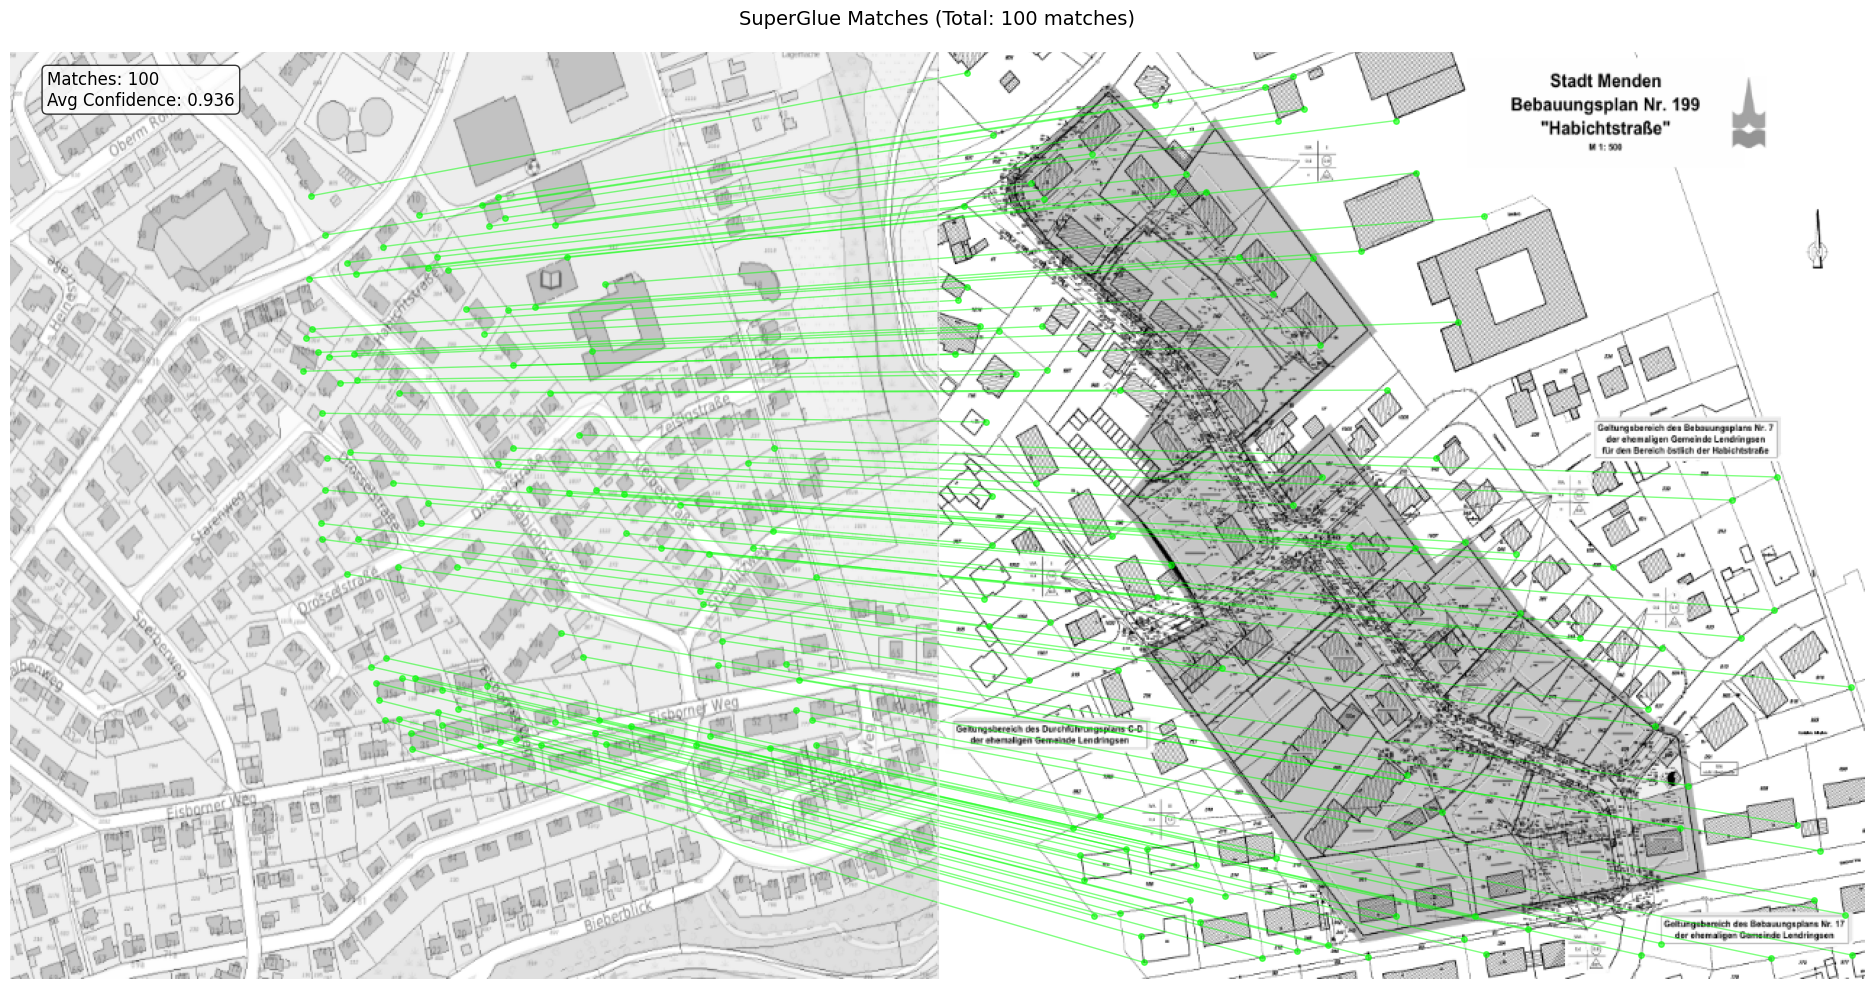


✅ Visualisierung erstellt!
Tipp: Ändere MAX_MATCHES in Zelle 2 oder VISUALIZATION_THRESHOLD hier


In [72]:
# ========================================
# VISUALISIERUNG
# ========================================

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_matches(img1, img2, kpts0, kpts1, confidence, threshold=0.3):
    """
    Visualisiert Keypoint-Matches zwischen zwei Bildern
    """
    # Filtere nach Threshold
    mask = confidence > threshold
    kpts0_filtered = kpts0[mask]
    kpts1_filtered = kpts1[mask]
    conf_filtered = confidence[mask]
    
    # Erstelle Figure
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 10))
    
    # Kombiniere beide Bilder nebeneinander
    if len(img1.shape) == 2:
        img1_rgb = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
        img2_rgb = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
    else:
        img1_rgb = img1
        img2_rgb = img2
    
    combined = np.hstack([img1_rgb, img2_rgb])
    ax.imshow(combined)
    
    # Zeichne Matches (alle grün)
    match_color = (0, 1, 0, 0.6)
    
    for i, (pt0, pt1, conf) in enumerate(zip(kpts0_filtered, kpts1_filtered, conf_filtered)):
        x0, y0 = pt0
        x1, y1 = pt1[0] + w1, pt1[1]
        ax.plot([x0, x1], [y0, y1], '-', color=match_color, linewidth=1, alpha=0.5)
        ax.plot(x0, y0, 'o', color=match_color, markersize=4)
        ax.plot(x1, y1, 'o', color=match_color, markersize=4)
    
    # Trennlinie
    ax.axvline(x=w1, color='white', linewidth=2, linestyle='--', alpha=0.5)
    
    # Titel
    ax.set_title(f'SuperGlue Matches (Total: {len(kpts0_filtered)} matches)', fontsize=14, pad=20)
    ax.axis('off')
    
    # Info-Box
    info_text = f"Matches: {len(kpts0_filtered)}\nAvg Confidence: {conf_filtered.mean():.3f}"
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return fig

# Visualisiere
VISUALIZATION_THRESHOLD = 0.2
fig = visualize_matches(img1_resized, img2_resized, mkpts0, mkpts1, match_confidence, 
                        threshold=VISUALIZATION_THRESHOLD)
plt.show()

print(f"\n✅ Visualisierung erstellt!")
print(f"Tipp: Ändere MAX_MATCHES in Zelle 2 oder VISUALIZATION_THRESHOLD hier")